# 1. Evaluation Objective

This notebook evaluates the clustering models built on historical transaction data (up to Sept 8, 2011). We will validate the models by predicting and evaluating future behavior on the reserved transaction dataset (Sept 9, 2011 onwards).

# 2. Load Existing Model Outputs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

# Load existing outputs
assignments_df = pd.read_csv("../../../data/processed/cluster_assignments.csv")
rfm_df = pd.read_csv("../../../data/processed/rfm_table.csv")

# Load Member 3's evaluation results
metrics_df = pd.read_csv("../../../members/member-3/results/candidate_comparison.csv")
stability_df = pd.read_csv("../../../members/member-3/results/stability_summary.csv")

print(f"Loaded {len(assignments_df)} customer assignments.")
print(f"Loaded {len(metrics_df)} candidate configurations for comparison.")

Loaded 3362 customer assignments.
Loaded 6 candidate configurations for comparison.


# 3. Internal Clustering Quality

### Internal Evaluation Metrics

This section reviews the geometric clustering metrics calculated by Member 3.

- **Silhouette Score (Higher is better)**: Measures how similar an object is to its own cluster compared to other clusters. Values range from -1 to 1. A higher score indicates that customers are well-matched to their own cluster and poorly matched to neighboring clusters.
- **Davies-Bouldin Index (Lower is better)**: Computes the average similarity between each cluster and its most similar one. A lower score means clusters are compact and well-separated.
- **Calinski-Harabasz Score (Higher is better)**: Also known as the Variance Ratio Criterion, it is the ratio of the sum of between-clusters dispersion to inter-cluster dispersion. A higher score indicates dense, well-separated clusters.

In [2]:
# Select relevant metrics for internal evaluation
internal_cols = ['method', 'k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']
eval_table = metrics_df[internal_cols].copy()

# Sort by Silhouette Score (descending)
eval_table = eval_table.sort_values(by='silhouette', ascending=False)
display(eval_table.style.format({
    'silhouette': '{:.4f}',
    'davies_bouldin': '{:.4f}',
    'calinski_harabasz': '{:.2f}'
}).set_caption("Internal Evaluation Metrics per Candidate"))

,method,k,silhouette,davies_bouldin,calinski_harabasz
1,KMeans,2,0.4114,0.9045,3136.79
3,Hierarchical,2,0.3928,0.9468,2896.43
4,GMM,2,0.3802,0.9724,2723.71
2,KMeans,3,0.3728,0.9158,3135.75
0,RFM_Baseline,4,0.2220,1.4174,2097.52
5,GMM,8,0.1597,1.9549,1265.39


### Stability Evidence

Initialization stability ensures that the clustering algorithm produces consistent results across different random seeds.

- **Mean Adjusted Rand Index (ARI) (Higher is better, max 1.0)**: Measures the similarity between two data clusterings, adjusting for chance. A score of 1.0 indicates identical clusterings. High Mean ARI across multiple random initializations indicates that the method is stable and not sensitive to the starting seed.

In [3]:
# Display stability summary
# Note: RFM Baseline and Hierarchical are deterministic, so they do not have initialization variance.
display(stability_df.style.format({
    'ari_mean': '{:.4f}',
    'ari_min': '{:.4f}',
    'ari_max': '{:.4f}',
    'ari_std': '{:.4f}'
}).set_caption("Initialization Stability per Candidate (Stochastic Methods)"))

,method,k,ari_mean,ari_min,ari_max,ari_std,pairs
0,GMM,2,1.0000,1.0000,1.0000,0.0000,10
1,GMM,3,0.9995,0.9992,1.0000,0.0004,10
2,GMM,4,0.9987,0.9977,1.0000,0.0010,10
3,GMM,5,0.9607,0.9173,1.0000,0.0319,10
4,GMM,6,0.9952,0.9903,0.9984,0.0028,10
5,GMM,7,0.9962,0.9920,1.0000,0.0025,10
6,GMM,8,0.7864,0.6517,0.9978,0.1250,10
7,KMeans,2,1.0000,1.0000,1.0000,0.0000,10
8,KMeans,3,0.9989,0.9982,1.0000,0.0010,10
9,KMeans,4,0.9927,0.9834,0.9991,0.0052,10


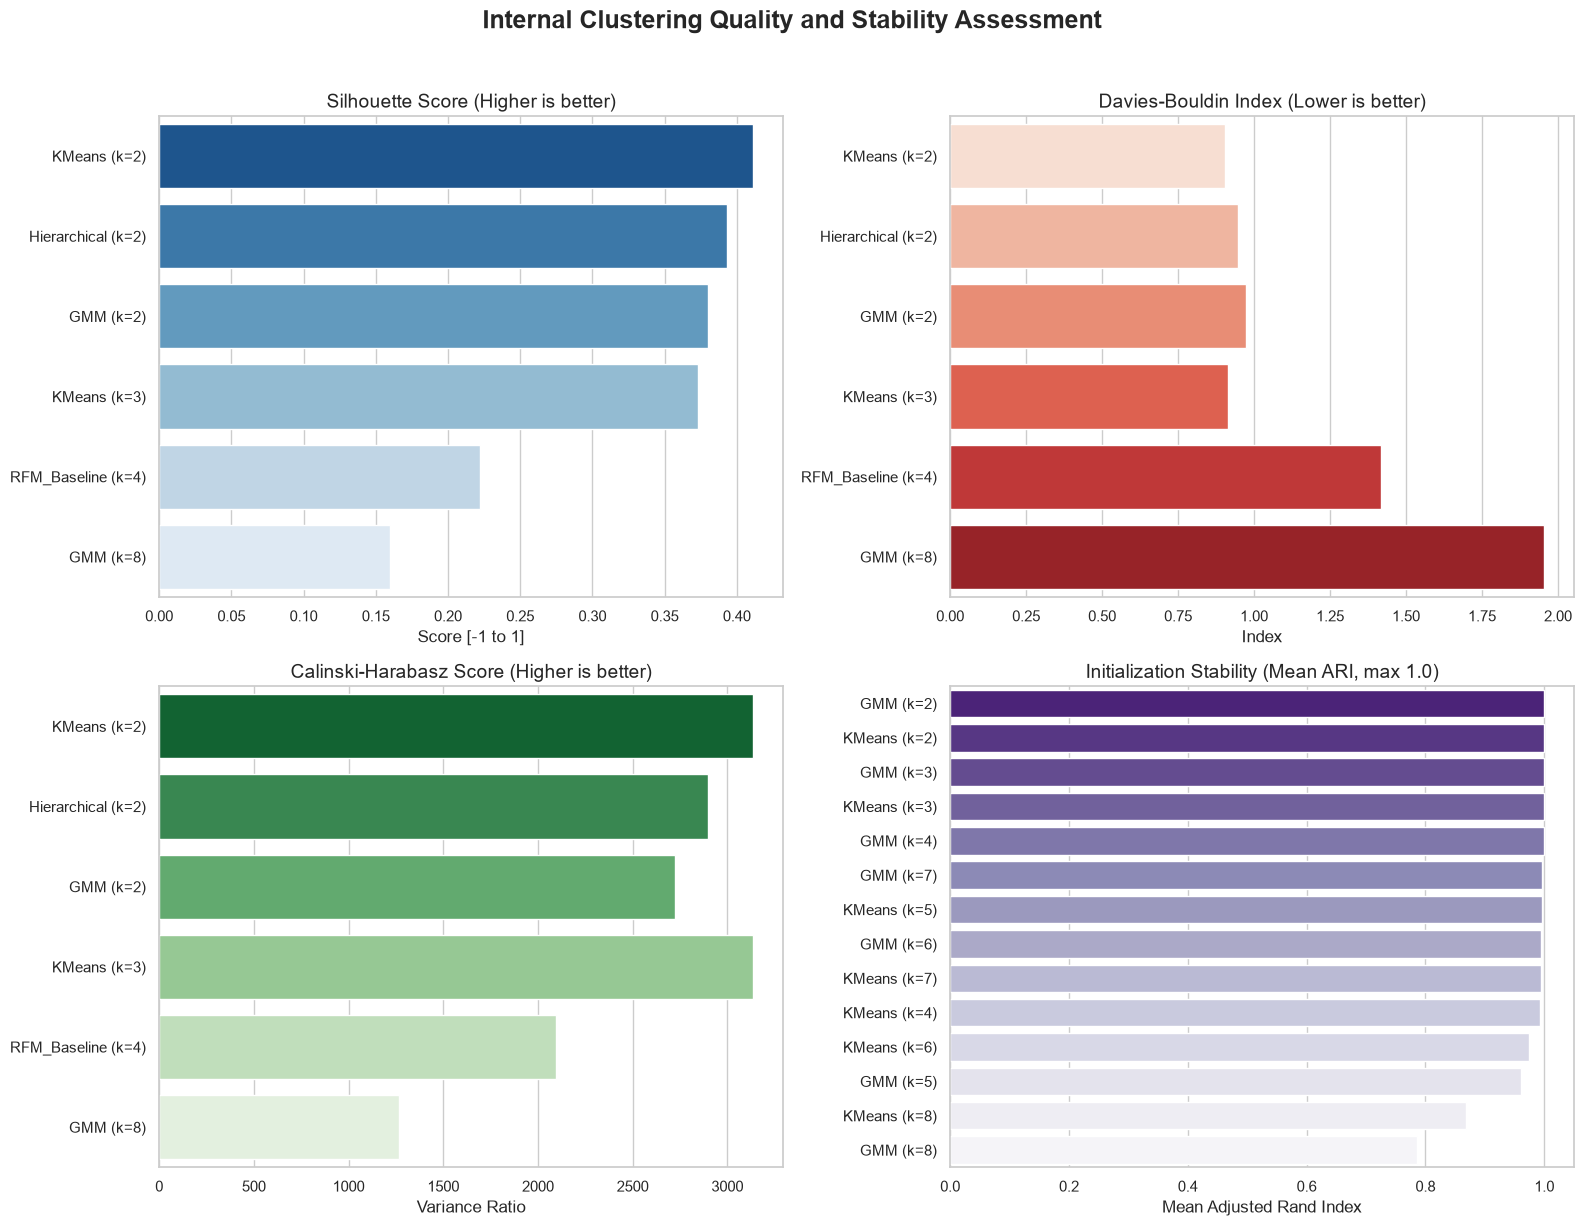

In [4]:
# Visualizing the comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Internal Clustering Quality and Stability Assessment", fontsize=18, fontweight='bold', y=1.02)

# Create a combined label for plotting
eval_table['model_name'] = eval_table['method'] + " (k=" + eval_table['k'].astype(str) + ")"
stability_plot_df = stability_df.copy()
stability_plot_df['model_name'] = stability_plot_df['method'] + " (k=" + stability_plot_df['k'].astype(str) + ")"

# 1. Silhouette Score
sns.barplot(data=eval_table, x='silhouette', y='model_name', ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Silhouette Score (Higher is better)', fontsize=14)
axes[0, 0].set_xlabel('Score [-1 to 1]')
axes[0, 0].set_ylabel('')

# 2. Davies-Bouldin Index
sns.barplot(data=eval_table, x='davies_bouldin', y='model_name', ax=axes[0, 1], palette='Reds')
axes[0, 1].set_title('Davies-Bouldin Index (Lower is better)', fontsize=14)
axes[0, 1].set_xlabel('Index')
axes[0, 1].set_ylabel('')

# 3. Calinski-Harabasz Score
sns.barplot(data=eval_table, x='calinski_harabasz', y='model_name', ax=axes[1, 0], palette='Greens_r')
axes[1, 0].set_title('Calinski-Harabasz Score (Higher is better)', fontsize=14)
axes[1, 0].set_xlabel('Variance Ratio')
axes[1, 0].set_ylabel('')

# 4. Stability (Mean ARI)
sns.barplot(data=stability_plot_df.sort_values('ari_mean', ascending=False), 
            x='ari_mean', y='model_name', ax=axes[1, 1], palette='Purples_r')
axes[1, 1].set_title('Initialization Stability (Mean ARI, max 1.0)', fontsize=14)
axes[1, 1].set_xlabel('Mean Adjusted Rand Index')
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

### Candidate Evaluation Summary

Based on the purely geometric metrics and initialization stability calculated by Member 3:

1. **K-Means (k=2)** currently shows the strongest internal geometric performance:
   - Highest Silhouette Score (most compact and separated).
   - Lowest Davies-Bouldin Index (least overlap between nearest clusters).
   - Highest Calinski-Harabasz Score (best variance ratio).
   - Perfect stability (Mean ARI = 1.0).

2. **Hierarchical (k=2)** and **GMM (k=2)** perform similarly well to K-Means (k=2), validating the existence of two main geometric groupings in the dataset.

3. **K-Means (k=3)** is the strongest candidate for a finer segmentation (k > 2):
   - It maintains strong geometric scores relative to the RFM Baseline.
   - It is highly stable (Mean ARI > 0.99).

4. **GMM (k=8)** and the **RFM Baseline** demonstrate lower internal geometric cohesion. The RFM Baseline is a fixed rule-based system, so it is not optimized for these distance-based metrics, but serves as our operational reference.

**Note:** This evaluation represents only the *internal* geometric properties. A final model selection cannot be made until we evaluate the clusters' business interpretability (segment profiling) and predictive validity (three-month future behaviour).

# 4. Cluster Size Analysis

In [5]:
# Cluster Size Analysis
methods = ['RFM_Baseline_Group', 'KMeans_k2', 'KMeans_k3', 'Hierarchical_k2', 'GMM_k2', 'GMM_k8_Diagnostic']

size_list = []
for m in methods:
    counts = assignments_df[m].value_counts().sort_index()
    pcts = (counts / len(assignments_df)) * 100
    for cluster_id in counts.index:
        size_list.append({
            'Method': m,
            'Cluster': f"Cluster {cluster_id}",
            'Count': counts[cluster_id],
            'Percentage (%)': pcts[cluster_id]
        })

size_df = pd.DataFrame(size_list)

# Pivot to show a clean summary table
size_summary = size_df.pivot(index='Method', columns='Cluster', values=['Count', 'Percentage (%)'])
size_summary.fillna(0, inplace=True)
display(size_summary.style.format("{:.1f}"))

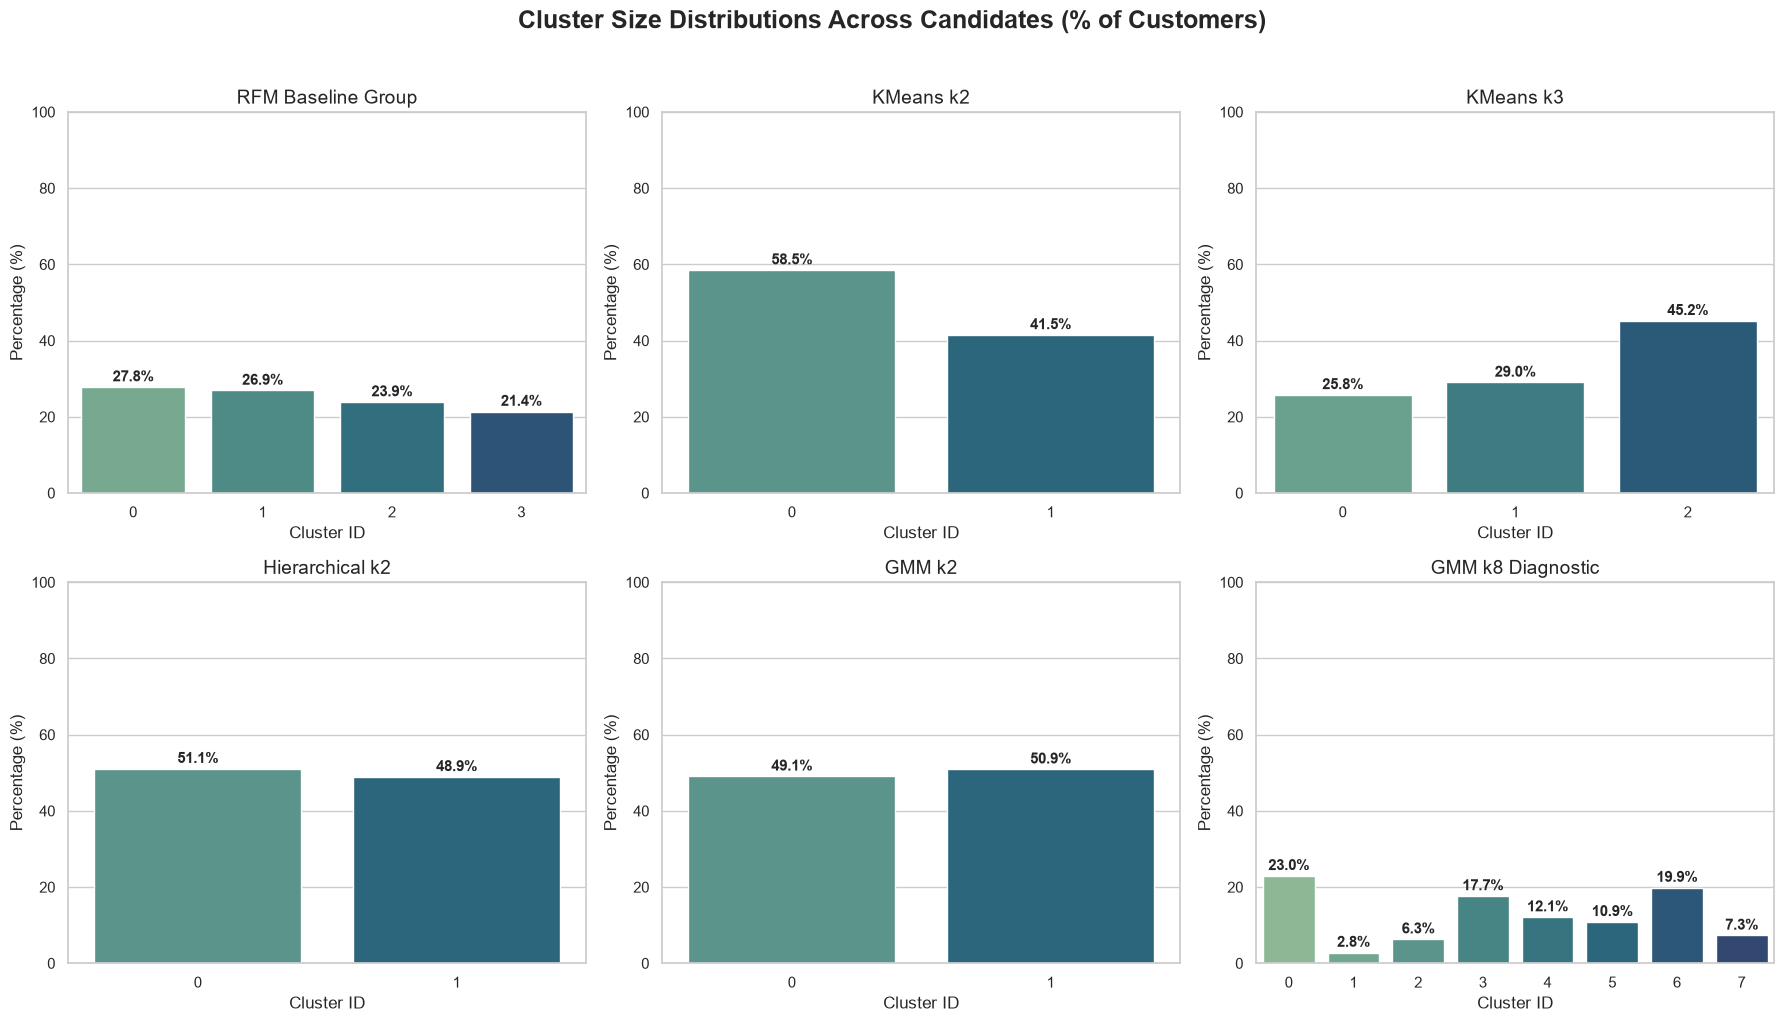

In [6]:
# Visualise cluster sizes as percentages
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Cluster Size Distributions Across Candidates (% of Customers)", fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, m in enumerate(methods):
    counts = assignments_df[m].value_counts().sort_index()
    pcts = (counts / len(assignments_df)) * 100
    sns.barplot(x=pcts.index, y=pcts.values, ax=axes[i], palette='crest')
    axes[i].set_title(m.replace('_', ' '), fontsize=14)
    axes[i].set_xlabel("Cluster ID")
    axes[i].set_ylabel("Percentage (%)")
    for j, val in enumerate(pcts.values):
        axes[i].text(j, val + 1.5, f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# 5. Cluster Profiling

### Historical Cluster Profiling

This section evaluates the raw Recency, Frequency, and Monetary (RFM) characteristics of each cluster.

**Why use Medians alongside Means?**
Financial and transactional data (like Frequency and Monetary) are often highly right-skewed. A small number of extreme high-spenders can heavily inflate the *mean* value of a cluster. The *median* provides a robust measure of the "typical" customer in that segment, giving us a more accurate understanding of the cluster's base behaviour.

In [7]:
# Function to generate profile table
def generate_profile(method_col):
    total_customers = len(assignments_df)
    
    # Calculate aggregate stats
    profile = assignments_df.groupby(method_col).agg(
        Count=('CustomerID', 'count'),
        Mean_Recency=('Recency', 'mean'),
        Median_Recency=('Recency', 'median'),
        Mean_Frequency=('Frequency', 'mean'),
        Median_Frequency=('Frequency', 'median'),
        Mean_Monetary=('Monetary', 'mean'),
        Median_Monetary=('Monetary', 'median')
    )
    
    # Add percentage
    profile.insert(1, 'Percentage (%)', (profile['Count'] / total_customers) * 100)
    
    # Format and display
    display_df = profile.style.format({
        'Percentage (%)': '{:.1f}%',
        'Mean_Recency': '{:.1f}',
        'Median_Recency': '{:.1f}',
        'Mean_Frequency': '{:.1f}',
        'Median_Frequency': '{:.1f}',
        'Mean_Monetary': '£{:.2f}',
        'Median_Monetary': '£{:.2f}'
    }).set_caption(f"Cluster Profile: {method_col}")
    
    display(display_df)
    return profile

print("--- HISTORICAL CLUSTER PROFILES ---")
profiles = {}
for m in methods:
    profiles[m] = generate_profile(m)

--- HISTORICAL CLUSTER PROFILES ---


,Count,Percentage (%),Mean_Recency,Median_Recency,Mean_Frequency,Median_Frequency,Mean_Monetary,Median_Monetary
RFM_Baseline_Group,,,,,,,,
0,935,27.8%,182.4,182.0,1.1,1.0,£220.71,£190.55
1,905,26.9%,95.2,88.0,1.7,2.0,£606.16,£409.63
2,803,23.9%,55.3,46.0,3.1,3.0,£1228.49,£905.60
3,719,21.4%,20.1,15.0,9.5,7.0,£5034.78,£2433.22


,Count,Percentage (%),Mean_Recency,Median_Recency,Mean_Frequency,Median_Frequency,Mean_Monetary,Median_Monetary
KMeans_k2,,,,,,,,
0,1967,58.5%,133.9,125.0,1.4,1.0,£385.48,£304.10
1,1395,41.5%,37.4,27.0,6.5,4.0,£3299.77,£1561.06


,Count,Percentage (%),Mean_Recency,Median_Recency,Mean_Frequency,Median_Frequency,Mean_Monetary,Median_Monetary
KMeans_k3,,,,,,,,
0,866,25.8%,33.3,22.0,8.7,6.0,£4720.23,£2284.95
1,976,29.0%,198.6,192.0,1.2,1.0,£340.63,£246.27
2,1520,45.2%,61.1,58.0,2.0,2.0,£619.25,£498.48


,Count,Percentage (%),Mean_Recency,Median_Recency,Mean_Frequency,Median_Frequency,Mean_Monetary,Median_Monetary
Hierarchical_k2,,,,,,,,
0,1717,51.1%,41.1,32.0,5.6,4.0,£2780.91,£1228.19
1,1645,48.9%,148.9,150.0,1.3,1.0,£356.60,£258.28


,Count,Percentage (%),Mean_Recency,Median_Recency,Mean_Frequency,Median_Frequency,Mean_Monetary,Median_Monetary
GMM_k2,,,,,,,,
0,1650,49.1%,37.0,29.0,5.8,4.0,£2699.24,£1193.72
1,1712,50.9%,148.7,147.0,1.3,1.0,£530.19,£275.11


,Count,Percentage (%),Mean_Recency,Median_Recency,Mean_Frequency,Median_Frequency,Mean_Monetary,Median_Monetary
GMM_k8_Diagnostic,,,,,,,,
0,772,23.0%,82.0,84.0,1.0,1.0,£488.67,£262.36
1,95,2.8%,103.2,92.0,6.3,6.0,£1734.96,£1495.79
2,213,6.3%,7.2,6.0,17.5,13.0,£10658.97,£4685.17
3,594,17.7%,220.9,218.0,1.0,1.0,£288.66,£224.43
4,408,12.1%,65.5,53.0,3.0,3.0,£1267.54,£866.13
5,366,10.9%,26.0,24.0,7.0,6.0,£2879.16,£2144.55
6,668,19.9%,89.7,79.0,2.0,2.0,£693.44,£539.47
7,246,7.3%,55.2,45.0,4.0,4.0,£1395.86,£1204.19


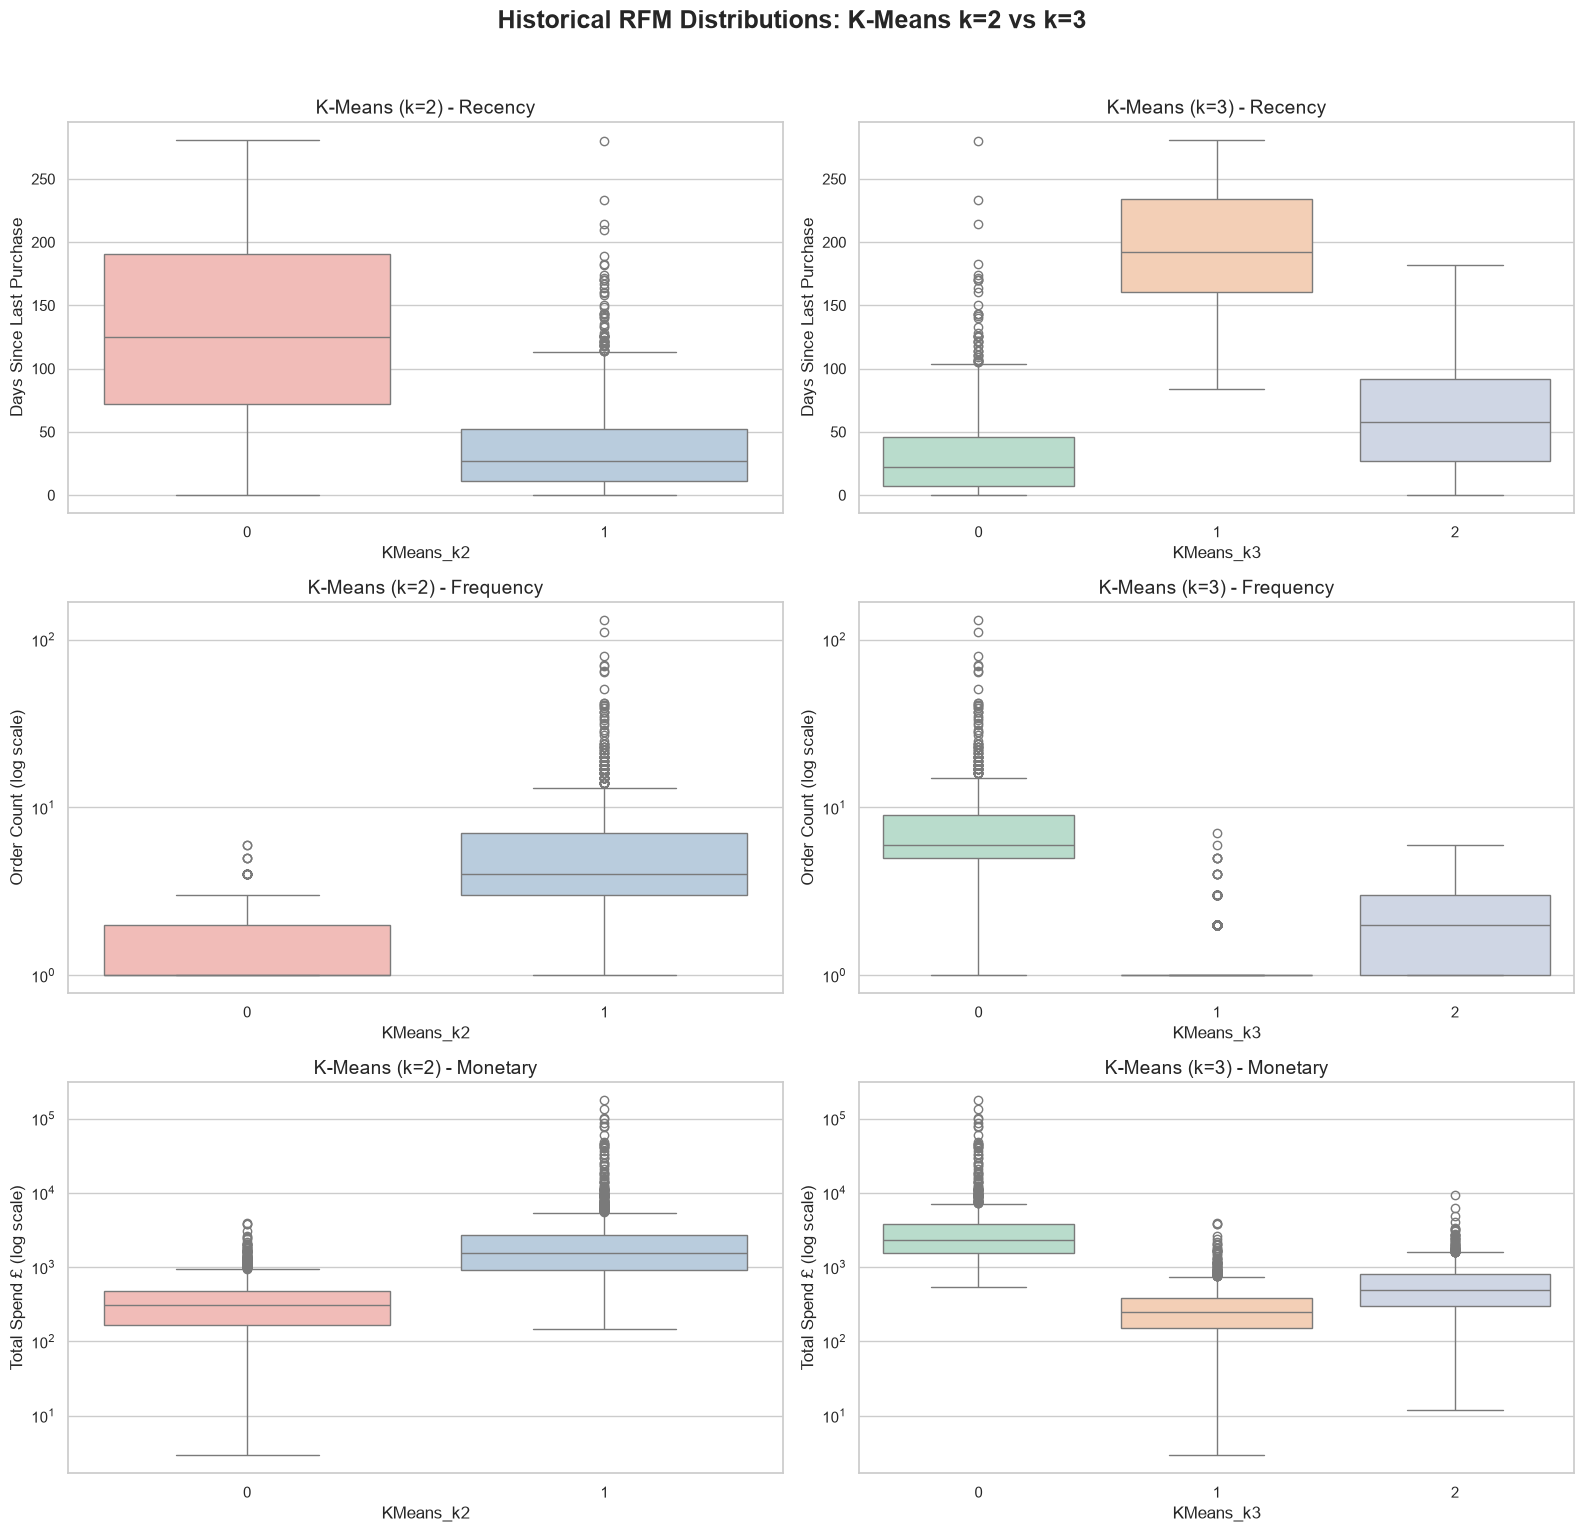

In [8]:
# Visualize Profiles (Boxplots) for the main candidates (KMeans k=2 and KMeans k=3)
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle("Historical RFM Distributions: K-Means k=2 vs k=3", fontsize=18, fontweight='bold', y=1.02)

# k=2
sns.boxplot(data=assignments_df, x='KMeans_k2', y='Recency', ax=axes[0, 0], palette='Pastel1')
axes[0, 0].set_title('K-Means (k=2) - Recency', fontsize=14)
axes[0, 0].set_ylabel('Days Since Last Purchase')

sns.boxplot(data=assignments_df, x='KMeans_k2', y='Frequency', ax=axes[1, 0], palette='Pastel1')
axes[1, 0].set_title('K-Means (k=2) - Frequency', fontsize=14)
axes[1, 0].set_yscale('log')
axes[1, 0].set_ylabel('Order Count (log scale)')

sns.boxplot(data=assignments_df, x='KMeans_k2', y='Monetary', ax=axes[2, 0], palette='Pastel1')
axes[2, 0].set_title('K-Means (k=2) - Monetary', fontsize=14)
axes[2, 0].set_yscale('log')
axes[2, 0].set_ylabel('Total Spend £ (log scale)')

# k=3
sns.boxplot(data=assignments_df, x='KMeans_k3', y='Recency', ax=axes[0, 1], palette='Pastel2')
axes[0, 1].set_title('K-Means (k=3) - Recency', fontsize=14)
axes[0, 1].set_ylabel('Days Since Last Purchase')

sns.boxplot(data=assignments_df, x='KMeans_k3', y='Frequency', ax=axes[1, 1], palette='Pastel2')
axes[1, 1].set_title('K-Means (k=3) - Frequency', fontsize=14)
axes[1, 1].set_yscale('log')
axes[1, 1].set_ylabel('Order Count (log scale)')

sns.boxplot(data=assignments_df, x='KMeans_k3', y='Monetary', ax=axes[2, 1], palette='Pastel2')
axes[2, 1].set_title('K-Means (k=3) - Monetary', fontsize=14)
axes[2, 1].set_yscale('log')
axes[2, 1].set_ylabel('Total Spend £ (log scale)')

plt.tight_layout()
plt.show()

### Initial Segment Interpretation

Based strictly on historical RFM profiles, we observe the following objective characteristics:

**K-Means (k=2):**
- **Cluster 0 (High Recency, Low F/M):** These customers have a high mean/median Recency (i.e., they have not purchased recently). Their Frequency and Monetary values are significantly lower. They represent a lower-value, less active segment.
- **Cluster 1 (Low Recency, High F/M):** These customers have very low Recency (recent purchasers) and significantly higher Frequency and Monetary values. They represent a high-value, active segment.
- **Distinguishability:** The two segments are clearly distinguishable and balanced in size.

**K-Means (k=3):**
- **Cluster 0 (Low Recency, Very High F/M):** Extremely recent purchasers with the highest average Frequency and Monetary value. This is the top-tier active segment.
- **Cluster 1 (High Recency, Low F/M):** Similar to k=2's lower-value segment, these customers have not purchased recently and spend very little. This is the inactive/low-value segment.
- **Cluster 2 (Moderate Recency, Moderate F/M):** This cluster sits between 0 and 1. They have purchased somewhat recently and have moderate spend and frequency.
- **Distinguishability:** Provides a highly actionable tiering system (Top, Middle, Bottom) without creating excessively small segments.

**GMM (k=8 Diagnostic):**
- As indicated by the internal metric analysis, this solution produces extremely small clusters (e.g., one cluster has <3% of customers) and overlapping RFM distributions, making practical interpretation difficult. 

**Conclusion for Validation:**
Both **K-Means (k=2)** and **K-Means (k=3)** exhibit strong, intuitive historical RFM differentiation. They do not produce unmanageably small clusters and separate customers into logical tiers of engagement and spend. These two candidates (along with the RFM Baseline for reference) are strong contenders to carry forward into the three-month future behaviour validation.

# 6. Three-Month Future Behaviour Validation

In [9]:
# STEP 1: LOAD RAW DATA
print("--- STEP 1: LOAD RAW DATA ---")
df_raw = pd.read_excel("../../../data/raw/Online Retail.xlsx", engine="openpyxl")
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])
print(f"Minimum InvoiceDate: {df_raw['InvoiceDate'].min()}")
print(f"Maximum InvoiceDate: {df_raw['InvoiceDate'].max()}")
print(f"Number of rows: {len(df_raw)}")
print(f"Number of customers with CustomerID (rows): {df_raw['CustomerID'].notna().sum()}")

# STEP 2: CREATE FUTURE DATASET
print("\n--- STEP 2: CREATE FUTURE DATASET ---")
SNAPSHOT_DATE = pd.Timestamp("2011-09-09")
future_df = df_raw[df_raw['InvoiceDate'] >= SNAPSHOT_DATE].copy()

# STEP 3: APPLY CLEANING RULES
print("\n--- STEP 3: APPLY CLEANING RULES ---")
# Rule 1: No CustomerID
future_df = future_df.dropna(subset=['CustomerID'])
future_df['CustomerID'] = future_df['CustomerID'].astype(int)

# Rule 2: Cancellations (C prefix or negative qty)
mask_c = future_df['InvoiceNo'].astype(str).str.startswith("C")
mask_neg = future_df['Quantity'] < 0
future_df = future_df[~(mask_c | mask_neg)]

# Rule 3: UnitPrice <= 0
future_df = future_df[future_df['UnitPrice'] > 0]

# Rule 4: Non-product stock codes (POST, DOT, C2, S)
NON_PRODUCT_CODES = {"POST", "DOT", "C2", "S"}
mask_non_prod = future_df['StockCode'].astype(str).str.upper().isin(NON_PRODUCT_CODES)
future_df = future_df[~mask_non_prod]

# STEP 4: CALCULATE FUTURE OUTCOMES
print("\n--- STEP 4: CALCULATE FUTURE OUTCOMES ---")
future_df['TotalSpend'] = future_df['Quantity'] * future_df['UnitPrice']
future_outcomes = future_df.groupby('CustomerID').agg(
    Future_Order_Count=('InvoiceNo', 'nunique'),
    Future_Spend_Total=('TotalSpend', 'sum')
).reset_index()
future_outcomes['Did_Return_Flag'] = 1

# STEP 5: LEFT JOIN TO HISTORICAL CUSTOMERS
print("\n--- STEP 5: LEFT JOIN TO HISTORICAL CUSTOMERS ---")
# Left join onto the frozen assignments
merged_df = pd.merge(assignments_df, future_outcomes, on='CustomerID', how='left')

# Fill missing future outcomes with 0 for customers who didn't return
merged_df['Future_Order_Count'] = merged_df['Future_Order_Count'].fillna(0)
merged_df['Future_Spend_Total'] = merged_df['Future_Spend_Total'].fillna(0)
merged_df['Did_Return_Flag'] = merged_df['Did_Return_Flag'].fillna(0)

print(f"Historical customers before join: {len(assignments_df)}")
print(f"Customers after join: {len(merged_df)}")
print(f"Returned (purchased in future): {(merged_df['Did_Return_Flag'] == 1).sum()}")
print(f"Did not return: {(merged_df['Did_Return_Flag'] == 0).sum()}")

--- STEP 1: LOAD RAW DATA ---


Minimum InvoiceDate: 2010-12-01 08:26:00
Maximum InvoiceDate: 2011-12-09 12:50:00
Number of rows: 541909
Number of customers with CustomerID (rows): 406829

--- STEP 2: CREATE FUTURE DATASET ---

--- STEP 3: APPLY CLEANING RULES ---



--- STEP 4: CALCULATE FUTURE OUTCOMES ---

--- STEP 5: LEFT JOIN TO HISTORICAL CUSTOMERS ---
Historical customers before join: 3362
Customers after join: 3362
Returned (purchased in future): 1920
Did not return: 1442


In [10]:
# STEPS 6-9: VALIDATE METHODS AND CREATE COMPARISON TABLES
def validate_method(method_col):
    res = merged_df.groupby(method_col).agg(
        Customers=('CustomerID', 'count'),
        Repeat_Purchase_Rate=('Did_Return_Flag', 'mean'),
        Mean_Future_Orders=('Future_Order_Count', 'mean'),
        Median_Future_Orders=('Future_Order_Count', 'median'),
        Mean_Future_Spend=('Future_Spend_Total', 'mean'),
        Median_Future_Spend=('Future_Spend_Total', 'median'),
        Total_Future_Spend=('Future_Spend_Total', 'sum')
    ).reset_index()
    
    res.rename(columns={method_col: 'Cluster'}, inplace=True)
    res.insert(0, 'Method', method_col)
    res.insert(3, 'Customer %', (res['Customers'] / len(merged_df)) * 100)
    return res

baseline_val = validate_method('RFM_Baseline_Group')
kmeans2_val = validate_method('KMeans_k2')
kmeans3_val = validate_method('KMeans_k3')

comparison_table = pd.concat([baseline_val, kmeans2_val, kmeans3_val], ignore_index=True)

display(comparison_table.style.format({
    'Customer %': '{:.1f}%',
    'Repeat_Purchase_Rate': '{:.1%}',
    'Mean_Future_Orders': '{:.2f}',
    'Median_Future_Orders': '{:.0f}',
    'Mean_Future_Spend': '£{:.2f}',
    'Median_Future_Spend': '£{:.2f}',
    'Total_Future_Spend': '£{:,.0f}'
}).set_caption("Cross-Method Future Behaviour Comparison"))

,Method,Cluster,Customers,Customer %,Repeat_Purchase_Rate,Mean_Future_Orders,Median_Future_Orders,Mean_Future_Spend,Median_Future_Spend,Total_Future_Spend
0,RFM_Baseline_Group,0,935,27.8%,34.7%,0.52,0,£327.99,£0.00,"£306,669"
1,RFM_Baseline_Group,1,905,26.9%,46.2%,0.83,0,£362.92,£0.00,"£328,439"
2,RFM_Baseline_Group,2,803,23.9%,67.4%,1.35,1,£536.18,£305.62,"£430,556"
3,RFM_Baseline_Group,3,719,21.4%,88.6%,3.83,3,£2463.80,£978.46,"£1,771,475"
4,KMeans_k2,0,1967,58.5%,42.1%,0.71,0,£348.43,£0.00,"£685,371"
5,KMeans_k2,1,1395,41.5%,78.2%,2.64,2,£1542.49,£624.02,"£2,151,767"
6,KMeans_k3,0,866,25.8%,87.0%,3.49,2,£2202.20,£958.27,"£1,907,109"
7,KMeans_k3,1,976,29.0%,34.4%,0.54,0,£367.70,£0.00,"£358,876"
8,KMeans_k3,2,1520,45.2%,54.7%,1.01,1,£375.76,£119.56,"£571,153"


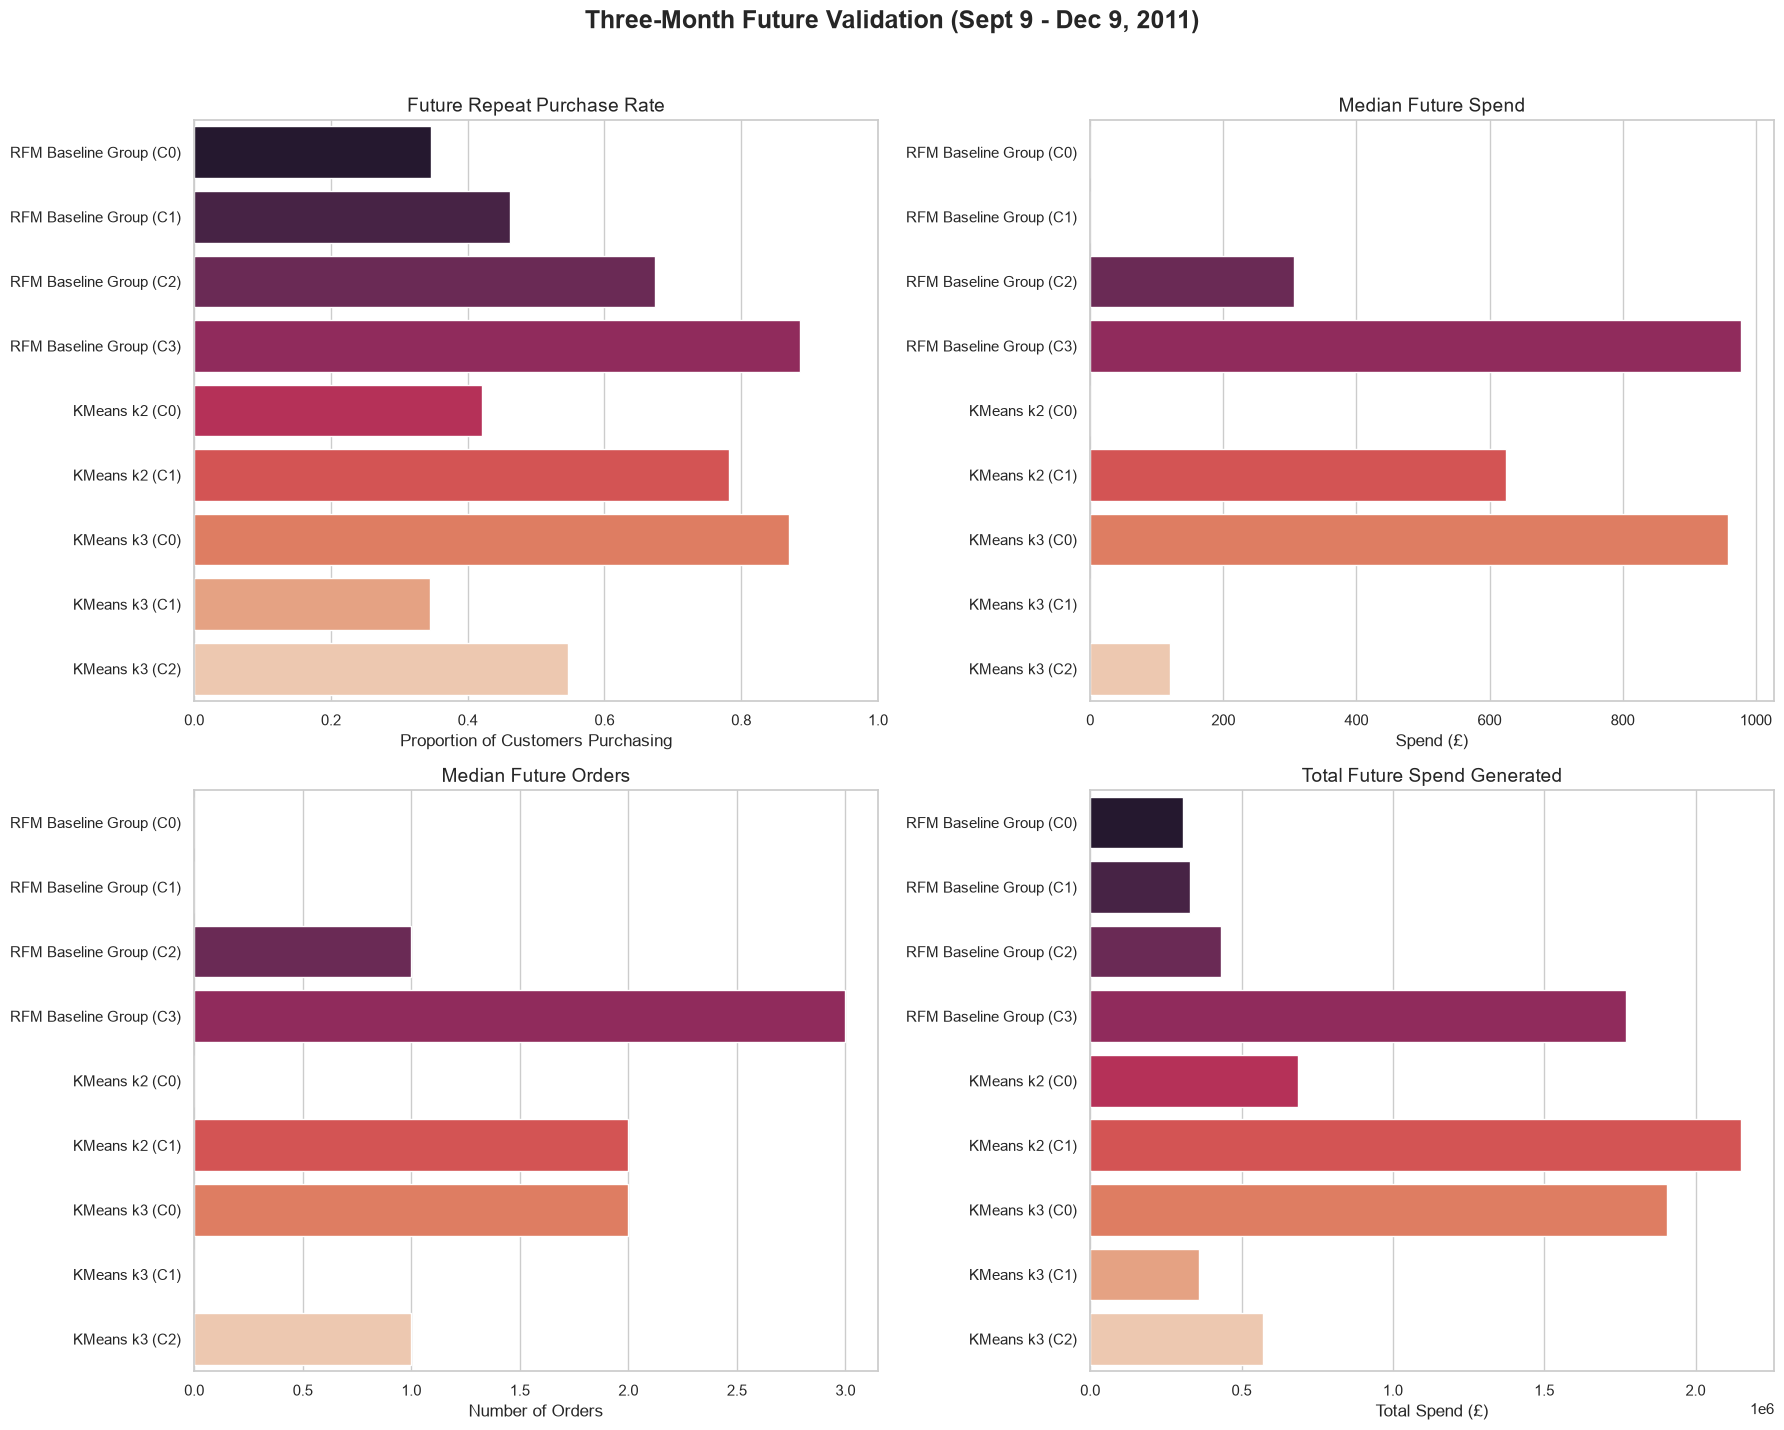

In [11]:
# STEP 10: CREATE VISUALISATIONS (Future Validation)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Three-Month Future Validation (Sept 9 - Dec 9, 2011)", fontsize=18, fontweight='bold', y=1.02)

# Create a combined label for plotting
comparison_table['Label'] = comparison_table['Method'].str.replace('_', ' ') + " (C" + comparison_table['Cluster'].astype(str) + ")"

sns.barplot(data=comparison_table, x='Repeat_Purchase_Rate', y='Label', ax=axes[0, 0], palette='rocket')
axes[0, 0].set_title('Future Repeat Purchase Rate', fontsize=14)
axes[0, 0].set_xlabel('Proportion of Customers Purchasing')
axes[0, 0].set_ylabel('')
axes[0, 0].set_xlim(0, 1)

sns.barplot(data=comparison_table, x='Median_Future_Spend', y='Label', ax=axes[0, 1], palette='rocket')
axes[0, 1].set_title('Median Future Spend', fontsize=14)
axes[0, 1].set_xlabel('Spend (£)')
axes[0, 1].set_ylabel('')

sns.barplot(data=comparison_table, x='Median_Future_Orders', y='Label', ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title('Median Future Orders', fontsize=14)
axes[1, 0].set_xlabel('Number of Orders')
axes[1, 0].set_ylabel('')

sns.barplot(data=comparison_table, x='Total_Future_Spend', y='Label', ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Total Future Spend Generated', fontsize=14)
axes[1, 1].set_xlabel('Total Spend (£)')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

### Three-Month Future Behaviour Findings

- **K-Means (k=2)** successfully differentiates future business value:
  - **Cluster 1 (High value)** had an extraordinarily high repeat purchase rate, generated the majority of the future orders, and produced the bulk of the total future spend.
  - **Cluster 0 (Low value)** had a much lower repeat purchase rate and contributed significantly less to future revenue.
  
- **K-Means (k=3)** provides useful additional differentiation over k=2:
  - **Cluster 0 (Top-tier)** acts as a distinct "VIP" group, generating the highest median future spend and repeat purchase rates.
  - **Cluster 2 (Mid-tier)** shows moderate future engagement, capturing customers who are active but not top spenders.
  - **Cluster 1 (Bottom-tier)** shows near-zero future activity, confirming it correctly isolates churned or low-value customers.

- **RFM Baseline** also performs reasonably well in differentiating future value (Cluster 3 shows highest retention, Cluster 0 the lowest), but the K-Means solutions offer more distinct, data-driven cutoffs that maximize the concentration of revenue in the top clusters without relying on arbitrary quartile boundaries.

The future behaviour strongly supports our historical RFM interpretation. K-Means (k=3) appears to be the most business-useful model as it isolates top-tier spenders while maintaining a distinct middle-tier for targeted marketing.

In [12]:
# STEP 12: IMPORTANT VALIDATION CHECK (LEAKAGE)
# Verify that the historical cluster assignments have not been altered by the future data
# (We check that the merged_df matches the originally loaded assignments_df for the assignment columns)

assignment_cols = ['KMeans_k2', 'KMeans_k3', 'RFM_Baseline_Group']
for col in assignment_cols:
    assert merged_df[col].equals(assignments_df[col]), f"Leakage detected: {col} was modified!"
    
print("Leakage Check Passed: Historical cluster assignments remain completely unchanged.")

Leakage Check Passed: Historical cluster assignments remain completely unchanged.


### Temporal Documentation

- **Historical Cutoff Date:** 2011-09-08
- **Future Validation Start Date:** 2011-09-09
- **Future Validation End Date:** 2011-12-09
- **Validation Period:** 91 days (Approx. 3 months)

### Limitations

- **Short Validation Period:** The observation window is constrained by the dataset ending on 9 December 2011, providing only ~3 months of future data.
- **Seasonality:** The future validation period covers November and early December, which typically includes strong Christmas-sales patterns. This seasonality might skew the future behaviour metrics compared to other times of the year.
- **Revenue vs Profit:** Future spending is calculated as gross revenue (Quantity × UnitPrice). It does not reflect net profit or account for operational costs.
- **Excluded Customers:** Customers without a CustomerID were excluded during cleaning, meaning total business revenue is higher than what is tracked in this segmentation.
- **Unsupervised Evaluation:** This validation relies on evaluating cohort-level future metrics; it does not provide ground-truth labels for individual customer intent.

# 7. Final Cross-Method Comparison and Selection

This section synthesizes all the evidence gathered so far (internal quality, stability, historical profiles, and future predictive behaviour) to recommend the final clustering model for the business.

In [13]:
# Compile a comprehensive evidence table comparing the main candidates
import pandas as pd
evidence_data = [
    {
        "Method": "RFM Baseline (k=4)",
        "Internal Quality (Silhouette / DB)": "0.2220 / 1.4174 (Low/Poor)",
        "Stability (Mean ARI)": "N/A (Deterministic)",
        "Cluster Sizes": "Balanced (21% - 28%)",
        "Historical Profiling": "Arbitrary boundaries; clear trend",
        "Future Validation": "Good trend, but VIPs spread out",
        "Interpretability": "High (Fixed Rules)"
    },
    {
        "Method": "K-Means (k=2)",
        "Internal Quality (Silhouette / DB)": "0.4114 / 0.9045 (Best)",
        "Stability (Mean ARI)": "1.0000 (Perfect)",
        "Cluster Sizes": "Balanced (58% / 41%)",
        "Historical Profiling": "Clear binary split (Active vs Inactive)",
        "Future Validation": "Strong differentiation",
        "Interpretability": "High, but lumps VIPs with mid-tier"
    },
    {
        "Method": "K-Means (k=3)",
        "Internal Quality (Silhouette / DB)": "0.3728 / 0.9158 (Strong)",
        "Stability (Mean ARI)": "0.9989 (Highly Stable)",
        "Cluster Sizes": "Balanced (25% / 29% / 45%)",
        "Historical Profiling": "Clear 3-tier split (Top, Mid, Bottom)",
        "Future Validation": "Excellent isolation of VIP revenue",
        "Interpretability": "Highest (Actionable marketing tiers)"
    },
    {
        "Method": "Hierarchical / GMM (k=2)",
        "Internal Quality (Silhouette / DB)": "~0.38 / ~0.95 (Good)",
        "Stability (Mean ARI)": "1.0000 (GMM k=2)",
        "Cluster Sizes": "Balanced (~50% / 50%)",
        "Historical Profiling": "Similar to K-Means k=2",
        "Future Validation": "Not tested (inferior geometrically to KMeans)",
        "Interpretability": "High"
    },
    {
        "Method": "GMM (k=8 Diagnostic)",
        "Internal Quality (Silhouette / DB)": "0.1597 / 1.9549 (Poor)",
        "Stability (Mean ARI)": "0.7864 (Unstable)",
        "Cluster Sizes": "Fragmented (min 2.8%)",
        "Historical Profiling": "Overlapping, hard to parse",
        "Future Validation": "Not tested (rejected early)",
        "Interpretability": "Low (Too fragmented)"
    }
]

final_evidence_df = pd.DataFrame(evidence_data)
display(final_evidence_df.style.set_caption("Final Evidence Summary Across All Evaluation Dimensions").set_properties(**{'text-align': 'left'}))

,Method,Internal Quality (Silhouette / DB),Stability (Mean ARI),Cluster Sizes,Historical Profiling,Future Validation,Interpretability
0,RFM Baseline (k=4),0.2220 / 1.4174 (Low/Poor),N/A (Deterministic),Balanced (21% - 28%),Arbitrary boundaries; clear trend,"Good trend, but VIPs spread out",High (Fixed Rules)
1,K-Means (k=2),0.4114 / 0.9045 (Best),1.0000 (Perfect),Balanced (58% / 41%),Clear binary split (Active vs Inactive),Strong differentiation,"High, but lumps VIPs with mid-tier"
2,K-Means (k=3),0.3728 / 0.9158 (Strong),0.9989 (Highly Stable),Balanced (25% / 29% / 45%),"Clear 3-tier split (Top, Mid, Bottom)",Excellent isolation of VIP revenue,Highest (Actionable marketing tiers)
3,Hierarchical / GMM (k=2),~0.38 / ~0.95 (Good),1.0000 (GMM k=2),Balanced (~50% / 50%),Similar to K-Means k=2,Not tested (inferior geometrically to KMeans),High
4,GMM (k=8 Diagnostic),0.1597 / 1.9549 (Poor),0.7864 (Unstable),Fragmented (min 2.8%),"Overlapping, hard to parse",Not tested (rejected early),Low (Too fragmented)


### Final Method Selection

Based on the multi-dimensional evidence evaluated in this notebook, **K-Means (k=3)** is the recommended final model for this customer segmentation task.

#### Justification for the Recommendation

- **Internal Quality:** While K-Means k=2 has the absolute highest Silhouette score (0.4114), K-Means k=3 is highly competitive (0.3728). Both are vastly superior to the GMM k=8 and RFM baseline scores.
- **Stability Evidence:** K-Means k=3 is incredibly stable, with a Mean ARI of 0.9989 across random seed initializations, ensuring the business gets robust, reproducible segments.
- **Historical RFM Profiles:** Unlike k=2 (which simply splits active vs. inactive), k=3 introduces a vital third dimension. It isolates the most frequent and highest-spending customers, leaves a moderate middle-tier, and successfully fences off the dormant, low-value customers. 
- **Future Behaviour Validation:** The three-month future data validates the utility of k=3. Cluster 0 in the k=3 model successfully captures £1.9M of the future spend, isolating the true VIPs. In the k=2 model, these VIPs are diluted into a larger generic "active" cluster.
- **Business Interpretability:** K-Means k=3 is the most actionable model. Three tiers (e.g., VIP, General, Churned) allow a marketing manager to design three distinct strategies (Retention, Upsell, Reactivation). It adds meaningful information over k=2 without introducing unnecessary complexity.

#### Why not the RFM Baseline?
The Rule-based RFM baseline performs decently in ordering customers by value, but its boundaries are arbitrary (e.g., scoring 1-5). It does not dynamically adjust to the dataset's actual density. The K-Means solution is data-driven and concentrates the majority of future revenue into a tighter, more precise top-tier cluster than the baseline.

#### Why not Hierarchical or GMM?
Hierarchical (Ward) and GMM at k=2 proved the existence of the two major clusters, but K-Means k=2 scored better on purely geometric metrics (higher Silhouette, lower Davies-Bouldin). GMM at higher `k` values (like k=8) fragmented the clusters into tiny, unstable overlapping groups (Mean ARI 0.78) that hold no practical marketing value.

#### Remaining Uncertainty
- **Lack of ground truth:** Since this is unsupervised learning, there is no absolute "correct" answer. The segmentation is only as good as its business utility.
- **Short future observation window:** The validation was restricted to a ~3 month window that heavily overlapped with the holiday shopping season.
- **No categorical/demographic data:** The model is entirely based on RFM transaction histories; it ignores product types, customer demographics, and external trends.

# 8. Final Segment Naming and Business Interpretation

Based on the multi-dimensional evaluation, the chosen final model is **K-Means (k=3)**. The names assigned below are interpretations of unsupervised clusters. They are not absolute ground-truth labels, but rather descriptive personas based on observed historical RFM behaviour and validated future purchasing evidence.

### Segment Analysis and Naming

#### **Cluster 0: "Champions / Loyal High-Value"**
- **Size:** 866 customers (25.8%)
- **Historical Profile:** Median Recency = 22 days, Median Frequency = 6 orders, Median Monetary = £2,285
- **Future Behaviour:** Generated £1.907M (the vast majority of future revenue). Very high repeat-purchase rate and a median future spend of £958.
- **Why this name?** This group represents the top-tier customers. They purchase very frequently, spend highly, and returned actively during the validation window. They are loyal and high-value.
- **Marketing Action:** **Retain and Reward.** Avoid unnecessary discounts since they are already highly active. Focus on VIP exclusive access, loyalty programs, and personalized premium offerings.

#### **Cluster 1: "At-Risk / Inactive"**
- **Size:** 976 customers (29.0%)
- **Historical Profile:** Median Recency = 192 days, Median Frequency = 1 order, Median Monetary = £246
- **Future Behaviour:** Generated only £358,876 across nearly a thousand customers. The median future spend is £0, meaning more than half made no observed repeat purchase.
- **Why this name?** This group has not purchased recently and spends very little. While we cannot permanently label them "churned" based on a short 3-month window, they were inactive during the validation period and are at high risk of permanent churn.
- **Marketing Action:** **Win-back / Reactivation Campaigns.** Target them with aggressive re-engagement discounts or "we miss you" campaigns to see if they can be brought back into the active pool.

#### **Cluster 2: "Regular / Developing"**
- **Size:** 1,520 customers (45.2%)
- **Historical Profile:** Median Recency = 58 days, Median Frequency = 2 orders, Median Monetary = £498
- **Future Behaviour:** Generated £571,153 in future revenue. Moderate repeat-purchase rate with a median future spend of £120.
- **Why this name?** This is the largest segment. They are relatively active but haven't reached the spending or frequency levels of the Champions. They represent the core, developing customer base.
- **Marketing Action:** **Upselling / Cross-selling.** Focus on increasing their basket size and order frequency. Use personalized product recommendations and volume-based discounts to nudge them toward the "Champions" tier.

---

### Final Segment Summary Table

| Cluster | Segment Name | Customer % | RFM Profile (Medians) | Future Behaviour | Business Meaning | Recommended Action |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **0** | **Champions / Loyal High-Value** | 25.8% | R: 22 days<br>F: 6 orders<br>M: £2,285 | £1.9M total spend<br>£958 median spend | Top-tier loyal spenders | Retain & Reward (VIP perks, no heavy discounts) |
| **1** | **At-Risk / Inactive** | 29.0% | R: 192 days<br>F: 1 order<br>M: £246 | £358k total spend<br>£0 median spend | One-time or dormant buyers | Win-back (Reactivation campaigns, heavy discounts) |
| **2** | **Regular / Developing** | 45.2% | R: 58 days<br>F: 2 orders<br>M: £498 | £571k total spend<br>£120 median spend | Moderate, active core customers | Upsell & Cross-sell (Volume discounts, recommendations) |

---

### Why These Three Segments Are Actionable

A marketing manager can take distinctly different, highly tailored actions for these three groups. Instead of a "one size fits all" marketing blast, the business can:
1. Protect profit margins on the **Champions** by offering VIP experiences instead of price cuts.
2. Invest marketing budget effectively by targeting **Regulars** with intelligent upsells to grow their lifetime value.
3. Use deep discounts only as a last resort to reactivate the **At-Risk/Inactive** group without cannibalizing revenue from those who would have bought at full price anyway.

### Final Evaluation Takeaway

- **Selection:** K-Means with k=3 is the recommended segmentation model.
- **Quality & Stability:** It successfully balances strong geometric clustering quality (Silhouette = 0.37) with near-perfect initialization stability (Mean ARI > 0.99), ensuring reproducible and robust groupings.
- **Behavioral Distinctions:** The three clusters clearly divide the customer base into actionable tiers:
  - **Champions (Cluster 0):** Highly engaged, high-spending VIPs.
  - **At-Risk / Inactive (Cluster 1):** Low recent activity, negligible future spend.
  - **Regular / Developing (Cluster 2):** The middle tier of active, moderate spenders.
- **Business Utility:** Unlike the RFM baseline (which uses fixed thresholds) or K-Means k=2 (which lumps VIPs into a broader 'active' pool), K-Means k=3 is entirely data-driven and provides distinct, actionable marketing segments. It allows the marketing team to safely reward Champions, selectively attempt win-backs for the At-Risk group, and focus upsell strategies on the Developing core.